In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read in data

In [3]:
# Read in Grav Data
df = pd.read_csv("eminegrav.csv")

df = df.rename(columns={
    "STN_ID": "Station Label",
    "TIME": "Time_str",
    "GRAV (mGal)": "obs (mGal)",
    "S.D": "S.D"
})

# STN_ID 50 covert to Base
df["Station Label"] = df["Station Label"].astype("object")


# Numeric columns
df["obs (mGal)"] = pd.to_numeric(df["obs (mGal)"], errors="coerce")
df["S.D"] = pd.to_numeric(df.get("S.D", np.nan), errors="coerce")

# Key for GPS merge (Base -> NaN; other stations -> numeric)
df["Station_Key"] = pd.to_numeric(df["Station Label"], errors="coerce")


# Read in GPS data
gps = pd.read_csv("EdgarGravGPS.csv").rename(columns={
    "Name": "Station_Key",
    "Easting": "Easting (m)",
    "Northing": "Northing (m)",
    "Elevation": "Elevation (m)"
})

gps["Station_Key"] = pd.to_numeric(gps["Station_Key"], errors="coerce")

# Keep only what we need
gps_small = gps[["Station_Key", "Easting (m)", "Northing (m)", "Elevation (m)"]].copy()


# merge gps and grav dataframe
df = df.merge(gps_small, on="Station_Key", how="left")


# convert time from HH:MM:SS to relative time 
df["Time_str"] = df["Time_str"].astype(str).str.strip()
t = pd.to_datetime(df["Time_str"], format="%H:%M:%S", errors="coerce")

if t.isna().any():
    print("⚠ Some times failed to parse (showing up to 10):")
    print(df.loc[t.isna(), ["Time_str", "Station Label"]].head(10))

t0 = t.dropna().iloc[0]
df["Time (h)"] = (t - t0).dt.total_seconds() / 3600

# Keep only rows with valid time + gravity
df = df.dropna(subset=["Time (h)", "obs (mGal)"]).reset_index(drop=True)


# Final data frame columns
df = df[[
    "Station Label",
    "Easting (m)",
    "Northing (m)",
    "Elevation (m)",
    "Time_str",
    "Time (h)",
    "obs (mGal)",
    "S.D"
]]

df.loc[df["Station Label"] == 50, "Station Label"] = "Base"

print(df.head(10))
data = df

⚠ Some times failed to parse (showing up to 10):
   Time_str Station Label
0       nan           NaN
40      nan           NaN
  Station Label  Easting (m)  Northing (m)  Elevation (m)  Time_str  Time (h)  \
0          Base   454960.481   4399923.231       2412.673  10:14:14  0.000000   
1          Base   454960.481   4399923.231       2412.673  10:46:30  0.537778   
2          48.0   454958.542   4399923.348       2413.051  10:50:33  0.605278   
3          46.0   454956.555   4399923.374       2413.392  10:54:59  0.679167   
4          44.0   454954.594   4399923.473       2413.734  10:59:09  0.748611   
5          42.0   454952.624   4399923.567       2414.068  11:03:33  0.821944   
6          40.0   454950.647   4399923.695       2414.384  11:07:00  0.879444   
7          Base   454960.481   4399923.231       2412.673  11:11:53  0.960833   
8          38.0   454948.680   4399923.782       2414.685  11:15:56  1.028333   
9          36.0   454946.710   4399923.903       2415.022  11:2

First, let's get the indices of the base stations, and the indices of everywhere else.

In [4]:
base_inds = np.where(data['Station Label'] == "Base")[0]
station_inds = np.where(data['Station Label'] != "Base")[0]
base_inds

array([ 0,  1,  7, 13, 19, 26, 32, 38], dtype=int64)

Now let's plot the observed value at each station, according to its northing location

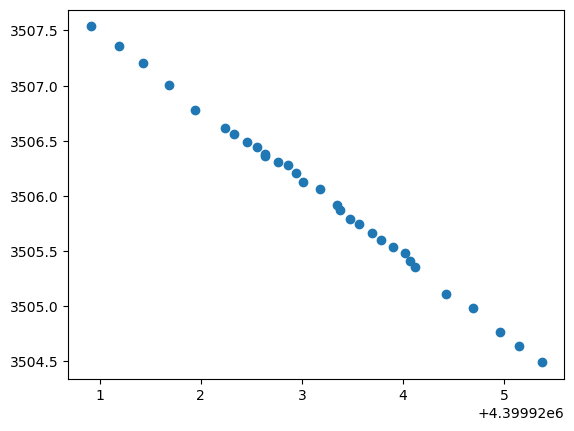

In [5]:
plt.scatter(data['Northing (m)'][station_inds], data['obs (mGal)'][station_inds])

# Drift-Correction

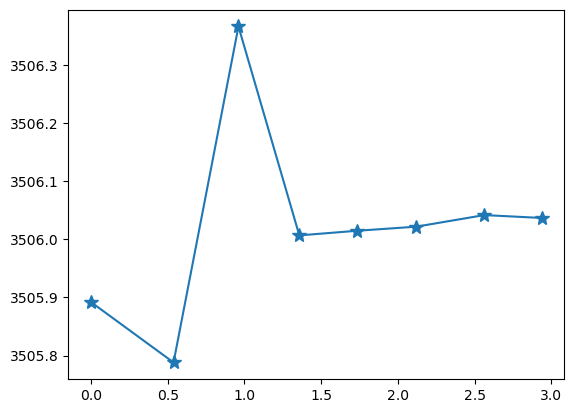

In [6]:
plt.plot(data['Time (h)'][base_inds], data['obs (mGal)'][base_inds], marker='*', markersize=10)

We can do some nice stuff with python here to make this easy!
So what do we want?
* Need a function that describes the base station as a function of time...
* Remove that variability from the observed data.

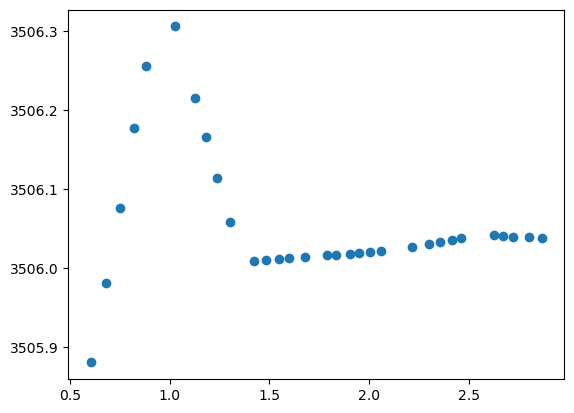

In [7]:
# part one sounds like an interpolation....
# Want to interpolate the values of the base station at times of the observations!
times = data['Time (h)']
obs = data['obs (mGal)']

g_drift = np.interp(times[station_inds], times[base_inds], obs[base_inds])

plt.scatter(times[station_inds], g_drift)

Text(0, 0.5, 'drift corrected (mGal)')

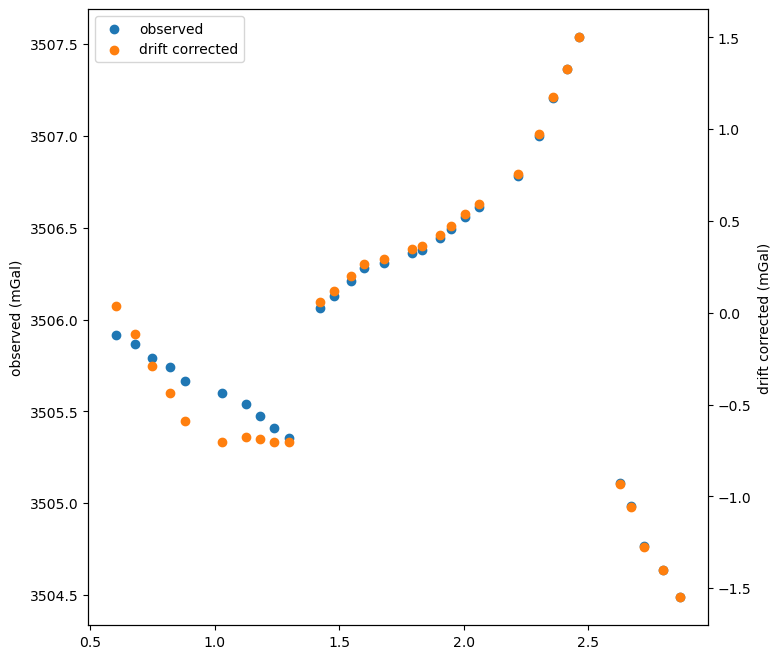

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

p1 = ax1.scatter(times[station_inds], obs[station_inds], color='C0', label='observed')
p2 = ax2.scatter(times[station_inds], obs[station_inds]-g_drift, color='C1', label='drift corrected')

ax1.legend(handles=[p1, p2])
ax1.set_ylabel('observed (mGal)')
ax2.set_ylabel('drift corrected (mGal)')

Now the other ones are pretty formulaic
# Free air

$$ \Delta g_{FA} = -0.3086 (mGal/m) * h $$

Text(0, 0.5, 'Elevations (m)')

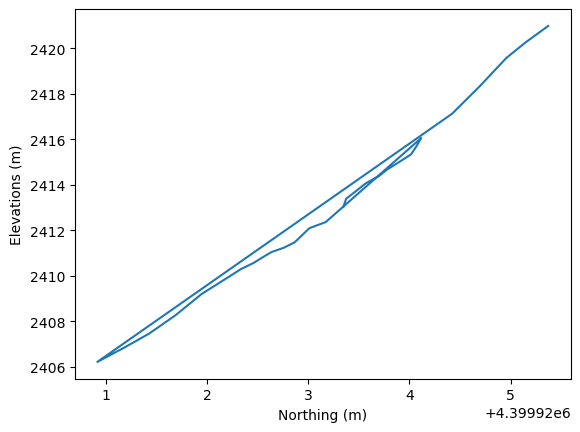

In [9]:
# Do the free air correction
profile = data['Northing (m)'][station_inds]
height = data['Elevation (m)'][station_inds]
plt.plot(profile, height)
plt.xlabel('Northing (m)')
plt.ylabel('Elevations (m)')

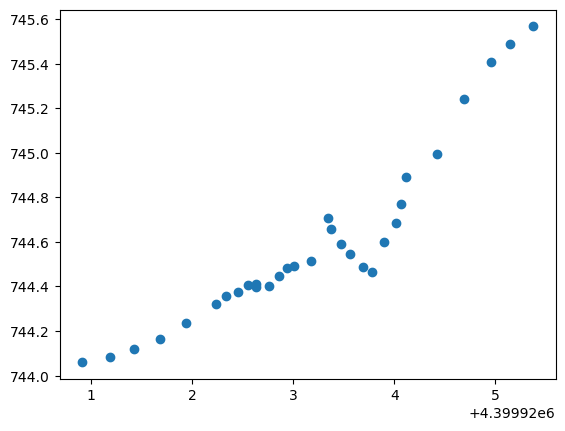

In [10]:
g_obs = data['obs (mGal)'][station_inds]

g_fa = -0.3086 * height


plt.scatter(profile, g_obs - g_drift - g_fa)

# Simple Bouguer correction

The simple bouguer correction removes an infinite slab with a thickness $h$ from the data.

$$\Delta g_{Bouguer} = 2 \pi \gamma \rho h$$

For $\rho = 2.67 g/cc$ this gives:

$$\Delta g_{booger} = 0.1119 (mGal/m) * h $$

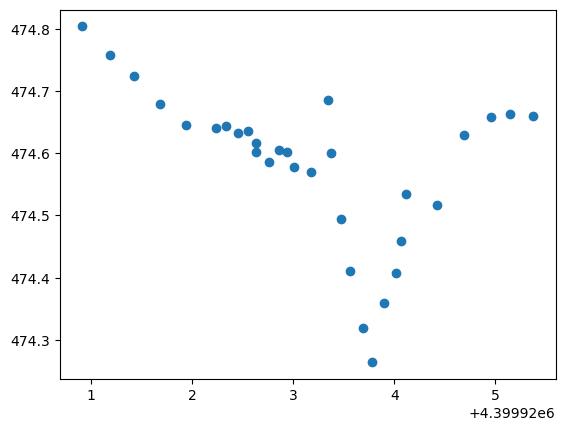

In [11]:
g_booger = 0.1119 * height # 2 pi gamma rho * h,  (rho=2.67)


plt.scatter(profile, g_obs - g_drift - g_fa - g_booger)

# Latitude correction

The full latitude correction is:

$$ \Delta g_{Lat} = g_e \left( \frac{1 + k \sin^2 \phi}{\sqrt{1-e^2 \sin^2 \phi}} - 1\right)$$

with $g_e = 978032.67714 mGal$, $k =  0.00193185138639$, and $e^2=0.00669437999013$ at latitude $\phi$


However for this data set, we do not know the latitude of each point, we are only given the latitude at the relative 0 North of the profile (45$\degrees$) and the distance north from each point, thus we will use the local approximation:

$$ \Delta g_{Lat} = 0.001626 (mGal/m) * \sin\phi\cos\phi * \Delta y$$

where $\Delta y$ is the difference in northing from the reference latitude point at $\phi$

this data has a reference point of 45$\degree

**note:** Remember to convert from degrees to radians for numpy!

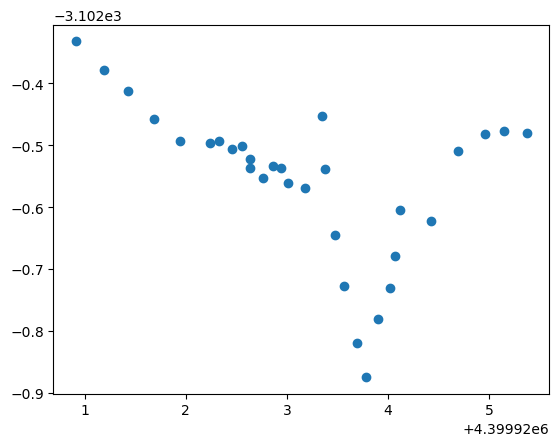

In [12]:
lat = np.pi/180 * 45

g_lat = 0.001626 * np.sin(lat) * np.cos(lat) * profile

plt.scatter(profile, g_obs - g_drift - g_fa - g_booger - g_lat)

plt.

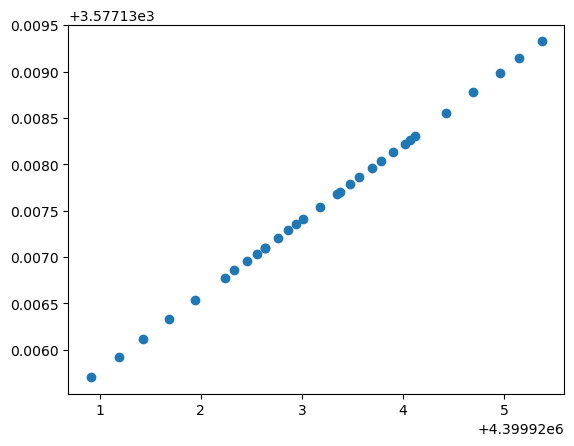

In [13]:
plt.scatter(profile, g_lat)

# Plot Cleaned Data as Heatmap

In [19]:
g_final = g_obs - g_drift - g_fa - g_booger - g_lat
st = df["Station Label"] != "Base"
df
df.loc[st, "g_final"] = g_obs - g_drift - g_fa - g_booger - g_lat

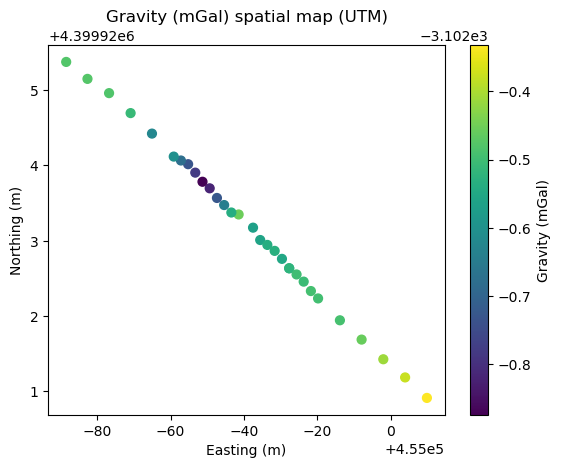

In [20]:
plt.figure()
sc = plt.scatter(df.loc[st, "Easting (m)"], df.loc[st, "Northing (m)"], c=g_final, s=40)
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Gravity (mGal) spatial map (UTM)")
plt.colorbar(sc, label="Gravity (mGal)")
plt.show()

# Save Cleaned Data as .CSV

In [21]:
df = df.iloc[2:]
df.to_csv("Grav_cleaned.csv", index=False)